Problema 2: Transformada de Fourier y complejidad algorítmica

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import time
#(a) Escriba un código en Python que genere una señal compuesta por dos frecuencias.
def señal_compuesta(f1,f2,N):
    #Establecemos las valores de las variables necesarias para generar la señal:
    fm=1000 # frecuencia de la muestra [Hz]
    T= 1  #Duración de la muestra [s]
    # Creamos el vector de los datos del tiempo de la muestra para generar la señal, el cual vendrá dado por:
    tm=np.arange(N)/fm
    #Ya con lo anterior establecido, la señal dada por xn será:
    xn=np.sin(2*np.pi*f1*tm)+0.5*np.sin(2*np.pi*f2*tm)
    return xn
# La función anterior genera  una señal compuesta pero en este caso la dejamos para que el usario elija los valores
# de las frecuencias de la señal y la cantidad de datos de la muestra (N), dejare una señal de ejemplo, donde N= int(fm*T) 
xs=señal_compuesta(50,200,1000)


In [44]:
#(b) Implemente la transformada discreta de Fourier directamente a partir de la definición 
# utilizando dos ciclos for.
def transformada_fourier(xs):
    N = len(xs)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X_sum = 0
        for n in range(N):
            factor_exp = -2j * np.pi * k * n / N
            X_sum += xs[n] * np.exp(factor_exp)
        X[k] = X_sum
    return X

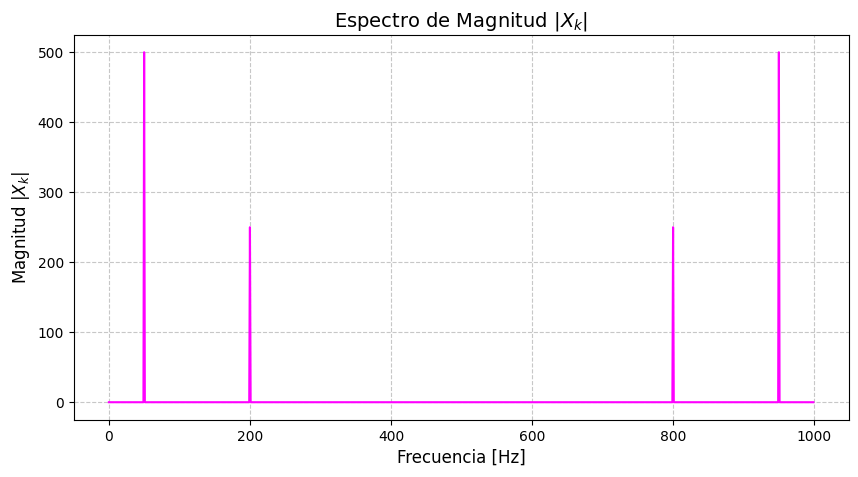

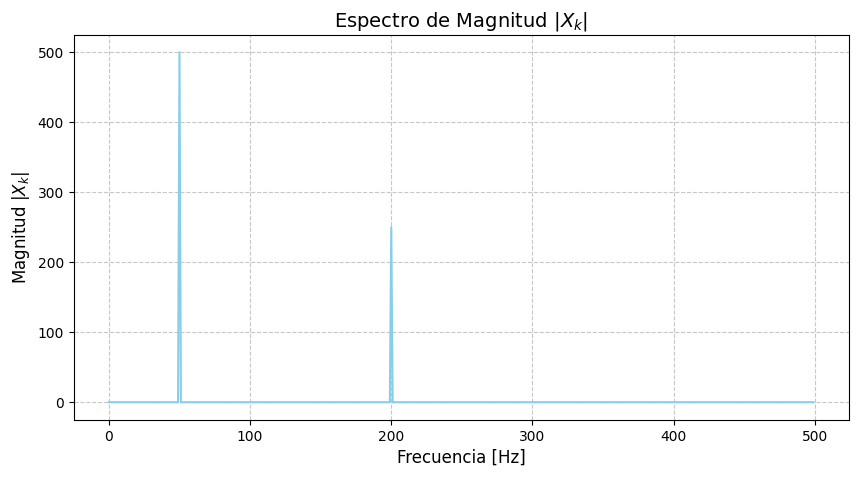

In [45]:
# (c) Grafique el espectro |X_k| obtenido.
# Eje Y 
X_k=transformada_fourier(xs)
magnitud = np.abs(X_k)# Calculamos el módulo (magnitud) de los números complejos dado por la transformada de la señal
# Eje X
N = len(magnitud)
frecuencias = np.arange(N) * (1000 / N)# Cada índice k corresponde a una frecuencia del tipo k * (fm / N)
plt.figure(figsize=(10, 5))
plt.plot(frecuencias[:N], magnitud[:N],color='fuchsia', linewidth=1.5)
plt.title('Espectro de Magnitud $|X_k|$', fontsize=14)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Magnitud $|X_k|$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# Notamos que DFT es simétrica , por ende, graficamos nuevamente solo la primera mitad, demostrando asi que solo con esa información entregada es suficiente  
mitad = N // 2
plt.figure(figsize=(10, 5))
plt.plot(frecuencias[:mitad], magnitud[:mitad],color='skyblue', linewidth=1.5)
plt.title('Espectro de Magnitud $|X_k|$', fontsize=14)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Magnitud $|X_k|$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [46]:
# (d) Calcule la transformada usando el algoritmo numpy.fft.fft.
X_fft = np.fft.fft(xs)

In [47]:
# (e) Compare el tiempo de ejecución entre su implementación directa de la DFT y el algoritmo
# FFT para distintos tamaños de señal (N = 10^2, 10^3, 10^4, 10^5)
# Definimos los tamaños de N 
tamaños_N = [100, 1000, 10000] # Nota: 10^5 lo omitimos en el manual, ya que tarda en copilar
tiempos_manual = []
tiempos_fft = []

for N in tamaños_N:
    señal_prueba=señal_compuesta(200,800,N)
    
    # Para obtener el tiempo de ejecuación de la DFT manual
    inicio_manual = time.time()
    X_manual = np.zeros(N, dtype=complex)
    if N <= 10000:
        for k in range(N):
            suma = 0
            for n in range(N):
                exponente = -2j * np.pi * k * n / N
                suma += señal_prueba[n] * np.exp(exponente)
            X_manual[k] = suma
        fin_manual = time.time()
        tiempos_manual.append(fin_manual - inicio_manual)
    else:
        tiempos_manual.append(None) 

    #Para medir el tiempo de ejecución de FFT numpy
    X_fft = np.fft.fft(señal_prueba)
    fin_fft = time.time()
    tiempos_fft.append(fin_fft - inicio_fft)

    print(f"N={N} completado. Manual: {tiempos_manual[-1]:.4f}s | FFT: {tiempos_fft[-1]:.4f}s")

N=100 completado. Manual: 0.0519s | FFT: 0.0001s
N=1000 completado. Manual: 3.8137s | FFT: 0.0001s
N=10000 completado. Manual: 390.1516s | FFT: 0.0015s


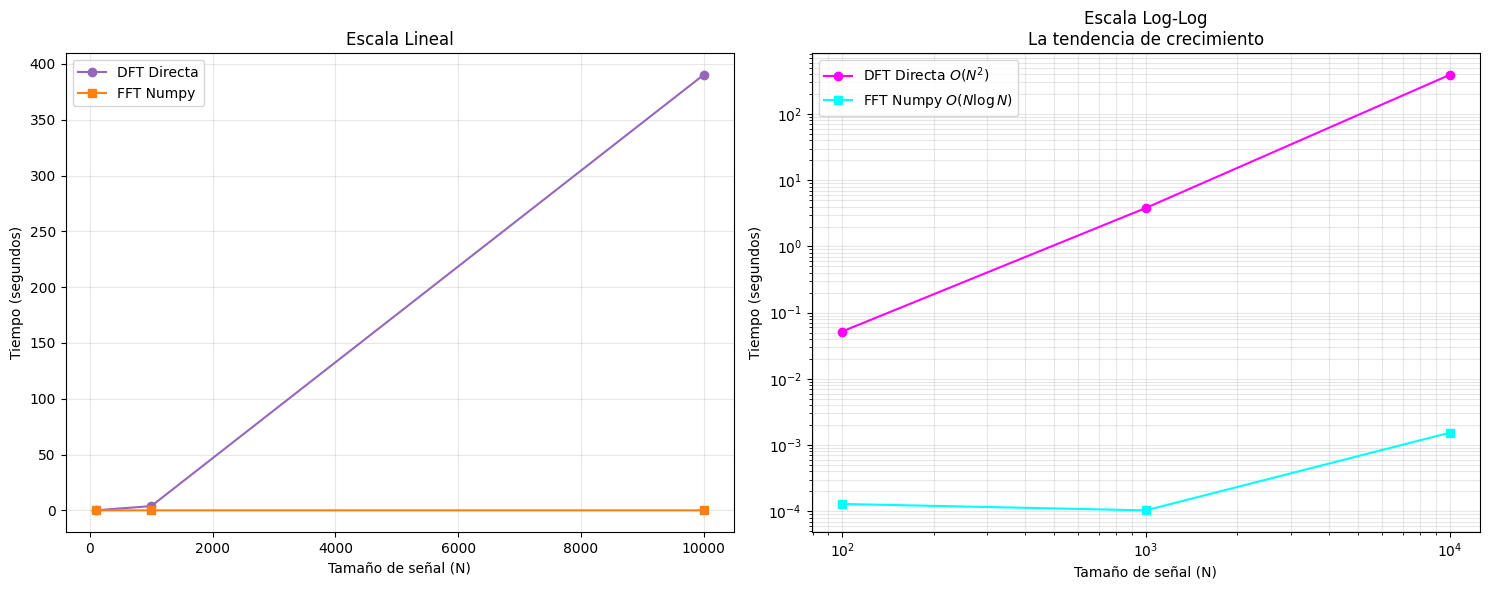

In [ ]:
# (f) Grafique el tiempo de ejecución en función de N para ambos algoritmos.
N_valores=np.array(tamaños_N)
# Crear una figura con dos espacios (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Gráfico de escala lineal
ax1.plot(N_valores, tiempos_manual, 'o-', label='DFT Directa', color='tab:purple')
ax1.plot(N_valores, tiempos_fft, 's-', label='FFT Numpy', color='tab:orange')
ax1.set_title('Escala Lineal', fontsize=12)
ax1.set_xlabel('Tamaño de señal (N)')
ax1.set_ylabel('Tiempo (s)')
ax1.grid(True, alpha=0.3)
ax1.legend()
# (g) Repita el gráfico en escala log-log y estime experimentalmente el exponente de escalamiento
# de cada algoritmo.
ax2.loglog(N_valores, tiempos_manual, 'o-', label='DFT Directa $O(N^2)$', color='fuchsia')
ax2.loglog(N_valores, tiempos_fft, 's-', label=r'FFT Numpy $O(N \log N)$', color='cyan')
ax2.set_title('Escala Log-Log\nLa tendencia de crecimiento', fontsize=12)
ax2.set_xlabel('Tamaño de señal (N)')
ax2.set_ylabel('Tiempo (s)')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


(g)

A partir del análisis del gráfico Log-Log, se pueden extraer las siguientes conclusiones sobre la complejidad algorítmica:

* **DFT Directa**: Presenta una pendiente de aproximadamente **2**, lo que corresponde a un escalamiento cuadrático **$O(N^2)$**. Esto confirma que al duplicar el tamaño de la señal ($N$), el tiempo de cómputo se cuadruplica.
* **FFT (Numpy)**: Muestra una pendiente cercana a **1.2**, lo que evidencia un escalamiento mucho más eficiente de tipo **$O(N \log N)$**. 
Por lo anterior podemos conluir, que el comportamiento de FFT numpy permite procesar grandes volúmenes de datos en una fracción más pqueña del tiempo comparado con la implementación directa.

In [60]:
# (h) Determine aproximadamente para qué valor de N la FFT se vuelve al menos 100 veces más rápida
#  que la DFT directa.
for i, N in enumerate(N_valores):
    ratio = tiempos_manual[i] / tiempos_fft[i]
    #  print(f"Para N={N}, la FFT es {ratio:.2f} veces más rápida.")
    if ratio >= 100:
        print(f"Para N={N}, la FFT es {ratio:.2f} veces más rápida,se cumple la condición.")
     


Para N=100, la FFT es 402.54 veces más rápida,se cumple la condición.
Para N=1000, la FFT es 36942.01 veces más rápida,se cumple la condición.
Para N=10000, la FFT es 254457.19 veces más rápida,se cumple la condición.


(i) Explique por qué el algoritmo FFT ha sido fundamental para el desarrollo de simulaciones en física, procesamiento de señales y análisis de datos experimentales.
Este algoritmo a sido fundamental dado que, brinda una eficiencia radical, pues el costo de cálculo lo reduce bastante lo cual pudimos evidenciar en este problema, donde para señales grandes, esto reduce el tiempo de espera de años a segundos Por otro lado, en física a sido de gran importancia para estudiar espectroscopía atómica, señales de astrofísica y análisis de imágenes. A su vez, permite resolver problemas complejos en el "espacio de frecuencias", lo que es vital para la simulación y el análisis de datos experimentales.